# 02 – Preprocessing

Turns the 44 raw works into model-ready data. The implementation lives in `src/preprocess.py` (run `python src/preprocess.py`); this notebook documents **what each stage does, why, and what it changes** (report snapshots).

**Decisions (fixed in advance)**

| # | Topic | Rule |
|---|---|---|
| 1 | Punctuation | keep `. , ; : !  ?` as separate tokens; drop every other mark (quotes, brackets, dashes); split hyphenated words; digits → `<num>` |
| 2 | Apostrophes | curly → straight; an apostrophe belongs to its word (`'tis o'er ne'er th' i' kill'd I'll Caesar's`); single quotes used as *quotation marks* are stripped |
| 3 | Case | lowercase everything, after saving a **case map** (most frequent casing of each word when it is *not* the first word of a verse line or sentence) |
| 4 | Sentences | punctuation-delimited (`. ! ?`), **not** verse lines; the lines of a speech are joined first and the end of a speech always ends a sentence |
| 5 | Removed | speaker tags, stage directions (incl. embedded ones), play titles, character lists, ACT/SCENE headers, scene-location lines, sonnet numbers |

**Pipeline** – each stage's output is saved in `data/interim/stageN_*/<slug>.txt`:

`raw → 1 normalize → 2 remove structure → 3 remove stage directions → 4 strip italics → 5 remove speaker tags → 6 split sentences → 7 tokenize → 8 lowercase → 9 vocabulary (train only, min_freq = 2)`

The vocabulary is built on the **train** split only (`data/split.csv`). The final files are `data/processed/{train,val,test}.txt` (one sentence per line, `<unk>`-mapped, no `<s>`/`</s>`; `src/data.py` adds them when loading).

In [1]:
import re, sys, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import preprocess as P
from src import data as D

DATA, INTERIM, PROCESSED = ROOT / "data", ROOT / "data" / "interim", ROOT / "data" / "processed"
FIG_DIR, TAB_DIR = ROOT / "figures", ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True); TAB_DIR.mkdir(exist_ok=True)
SEED = 42
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


# the pipeline is run from the command line; run it here only if its outputs are missing
if not (PROCESSED / "vocab.json").exists():
    P.main()

meta = pd.read_csv(DATA / "metadata.csv", encoding="utf-8")
split_df = pd.read_csv(DATA / "split.csv", encoding="utf-8")
split_of = dict(zip(split_df["slug"], split_df["split"]))
is_play = {s: c != "Poetry" for s, c in zip(meta["slug"], meta["category"])}
raw = {s: P.read(DATA / "works" / f"{s}.txt") for s in meta["slug"]}
print(f"{len(raw)} raw works; processed files: {sorted(p.name for p in PROCESSED.glob('*.txt'))}")

44 raw works; processed files: ['test.txt', 'train.txt', 'val.txt', 'wikitext2_test.txt', 'wikitext2_train.txt', 'wikitext2_val.txt']


## 1. What the raw files look like (checks behind the rules)

Before choosing rules, three questions about the raw text.

### 1.1 Do the `_italic_` markers mostly mark stage directions?

In [2]:
ITALIC_RE = re.compile(r"_[^_]+_")
rows = []
for cat, g in meta.groupby("category"):
    inside = outside = 0
    for s in g["slug"]:
        t = raw[s]
        inside += sum(len(ITALIC_RE.findall(m.group(0))) for m in P.BRACKET_RE.finditer(t))
        outside += len(ITALIC_RE.findall(P.BRACKET_RE.sub("", t)))
    rows.append({"category": cat, "italic_spans_inside_[brackets]": inside, "italic_spans_outside_brackets": outside})
italics = pd.DataFrame(rows)
tot = italics.drop(columns="category").sum()
italics.loc[len(italics)] = ["ALL", *tot.values]
italics["pct_inside_brackets"] = (100 * italics.iloc[:, 1] / (italics.iloc[:, 1] + italics.iloc[:, 2])).round(1)
display(italics)
save_table(italics, "preprocessing_italics_check.csv")

outside_spans = Counter()
for s in meta["slug"]:
    for m in ITALIC_RE.finditer(P.BRACKET_RE.sub("", raw[s])):
        outside_spans[m.group(0).strip("_").strip()[:45].replace("\n", " ")] += 1
print("Examples of italics OUTSIDE brackets:", [w for w, _ in outside_spans.most_common(12)])

,category,italic_spans_inside_[brackets],italic_spans_outside_brackets,pct_inside_brackets
0,Comedy,1074,354,75.2
1,History,1068,167,86.5
2,Poetry,0,1,0.0
3,Romance,544,101,84.3
4,Tragedy,1490,52,96.6
5,ALL,4176,675,86.1


saved table  -> tables/preprocessing_italics_check.csv
Examples of italics OUTSIDE brackets: ['l’envoi', 'solus', 'et', 'madame.', 'fico', 'videlicet', 'ipse', 'When as a lion’s whelp shall, to himself unkn', 'mollis aer', 'mulier', 'Videlicet', 'Sauf votre honneur']


Almost all italics sit inside `[...]` and are stage directions. The few italic spans outside brackets are Latin/French phrases, letters and songs (*L'envoi, solus, Hic et ubique?, Pauca verba ...*), i.e. real spoken text. **Rule:** detect directions through the brackets (and the un-bracketed `Enter/Exit/Exeunt …` paragraphs) first; afterwards strip the remaining underscores and **keep the words inside**.

### 1.2 Single quotes as quotation marks

In [3]:
rows = []
for s, cat in zip(meta["slug"], meta["category"]):
    _, (n_open, n_close) = P.stage1_normalize(raw[s])
    rows.append({"slug": s, "category": cat, "openers": n_open, "closers_removed": n_close})
q = pd.DataFrame(rows)
q_cat = q.groupby("category").agg(works=("slug", "count"), openers=("openers", "sum"),
                                  closers_removed=("closers_removed", "sum")).reindex(["Comedy", "Tragedy", "History", "Romance", "Poetry"])
display(q_cat)
display(q[q["category"] == "Poetry"].query("openers > 0")[["slug", "openers", "closers_removed"]])
save_table(q_cat, "preprocessing_quote_stats.csv", index=True)
lc = raw["lover_s_complaint"]
i = lc.index("\u2018")
print("\nA Lover's Complaint, where the long quoted speech begins (raw -> stage 1):")
print(lc[i - 60:i + 120]); print("--->"); print(P.stage1_normalize(lc[i - 60:i + 120])[0])

,works,openers,closers_removed
category,,,
Comedy,12,146,146
Tragedy,11,145,145
History,10,1,1
Romance,5,28,28
Poetry,6,52,18


,slug,openers,closers_removed
0,sonnets,7,7
39,lover_s_complaint,41,7
42,rape_of_lucrece,4,4


saved table  -> tables/preprocessing_quote_stats.csv

A Lover's Complaint, where the long quoted speech begins (raw -> stage 1):
monarchs’ hands, that lets not bounty fall
Where want cries ‘some,’ but where excess begs ‘all’.

Of folded schedules had she many a one,
Which she perus’d, sigh’d, tore and gave t
--->
monarchs' hands, that lets not bounty fall
Where want cries some, but where excess begs all.

Of folded schedules had she many a one,
Which she perus'd, sigh'd, tore and gave t


Single quotes are used as quotation marks mostly in the **plays**; in the narrative poems they appear in *A Lover's Complaint* (a long speech that re-opens the quote at the start of every stanza), *The Rape of Lucrece* and the Sonnets. Opening marks (U+2018) are unambiguous and are always removed; a right single quote (U+2019) is removed only when a quote is open **and** it looks like a closer (after punctuation, or before punctuation/space and not an elision such as `o'` / `th'`). All other apostrophes are kept.

### 1.3 Where do directions and tags live?

In [4]:
t = P.stage1_normalize(raw["hamlet_prince_of_denmark"])[0].splitlines()
i = next(k for k, l in enumerate(t) if l.startswith("SCENE I."))
print("\n".join(t[i - 4:i + 22]))



ACT I

SCENE I. Elsinore. A platform before the Castle.


Enter Francisco and Barnardo, two sentinels.

BARNARDO.
Who's there?

FRANCISCO.
Nay, answer me. Stand and unfold yourself.

BARNARDO.
Long live the King!

FRANCISCO.
Barnardo?

BARNARDO.
He.

FRANCISCO.
You come most carefully upon your hour.


Layout of the plays: front matter (title, *Contents*, *Dramatis Personae*, `SCENE: ...` setting line), `ACT`/`SCENE` headers (the location is on the header line and sometimes wraps), un-bracketed `Enter ...` paragraphs, bracketed `[_Exit._]` directions (also inline, e.g. `[_Aside._] text`), and `SPEAKER.` tags alone on a line. A speech can contain blank lines when a direction interrupts it, so **speech boundaries are the next speaker tag or header, not blank lines**.

## 2. Stage-by-stage snapshots
The same passage after every stage. (Stages 2–4 mark removed headers with a `<BREAK>` line = hard boundary between speeches; stage 5 emits one block per speech; stage 6 one sentence per line; 7 and 8 are token streams; the last block is the final vocabulary-mapped file.)

In [5]:
STAGE_DIRS = P.STAGES
STAGE_TITLES = {0: "raw", 1: "1 normalized", 2: "2 structure removed", 3: "3 stage directions removed",
                4: "4 italics stripped", 5: "5 speaker tags removed (1 block = 1 speech)", 6: "6 sentences",
                7: "7 tokenized (cased)", 8: "8 lowercased"}


def load_stage(n, slug):
    path = (DATA / "works" / f"{slug}.txt") if n == 0 else (INTERIM / STAGE_DIRS[n] / f"{slug}.txt")
    return P.read(path).splitlines()


import textwrap


def nz(s):
    return re.sub(r"[^a-z]", "", s.lower())


def show_lines(lines, wrap):
    for l in lines:
        if not l.strip():
            print()
        elif wrap and len(l) > 118:
            print(textwrap.fill(l, 118, subsequent_indent="    "))
        else:
            print(l[:130])


def snapshot(slug, anchor, before, after, sent_before=None, sent_after=None):
    sb = before if sent_before is None else sent_before
    sa = after if sent_after is None else sent_after
    key = nz(anchor)
    for n in range(0, 9):
        lines = load_stage(n, slug)
        idx = next((k for k, l in enumerate(lines) if key in nz(l)), None)
        b, a = (sb, sa) if n >= 6 else (before, after)
        print(f"\n===== {STAGE_TITLES[n]} =====")
        if idx is None:
            print("(anchor not found)")
            continue
        show_lines(lines[max(0, idx - b): idx + a + 1], wrap=n >= 6)
    # final, <unk>-mapped
    sp = split_of[slug]
    row = D.load_works_index().query("split == @sp and slug == @slug").iloc[0]
    sents = P.read(PROCESSED / f"{sp}.txt").splitlines()[row.first_line: row.first_line + row.n_sentences]
    k = next((i for i, l in enumerate(sents) if key in nz(l)), None)
    print(f"\n===== 9 final ({sp}.txt, <unk>-mapped, no <s> </s>) =====")
    if k is not None:
        show_lines(sents[max(0, k - sb): k + sa + 1], wrap=True)


print("SAMPLE A - Hamlet, opening of the play (header, Enter, speaker tags, 'Tis)")
snapshot("hamlet_prince_of_denmark", "Nay, answer me", 13, 12, 4, 6)

SAMPLE A - Hamlet, opening of the play (header, Enter, speaker tags, 'Tis)

===== raw =====


ACT I

SCENE I. Elsinore. A platform before the Castle.


Enter Francisco and Barnardo, two sentinels.

BARNARDO.
Who’s there?

FRANCISCO.
Nay, answer me. Stand and unfold yourself.

BARNARDO.
Long live the King!

FRANCISCO.
Barnardo?

BARNARDO.
He.

FRANCISCO.
You come most carefully upon your hour.

===== 1 normalized =====


ACT I

SCENE I. Elsinore. A platform before the Castle.


Enter Francisco and Barnardo, two sentinels.

BARNARDO.
Who's there?

FRANCISCO.
Nay, answer me. Stand and unfold yourself.

BARNARDO.
Long live the King!

FRANCISCO.
Barnardo?

BARNARDO.
He.

FRANCISCO.
You come most carefully upon your hour.

===== 2 structure removed =====
<BREAK>

<BREAK>

<BREAK>

Enter Francisco and Barnardo, two sentinels.

BARNARDO.
Who's there?

FRANCISCO.
Nay, answer me. Stand and unfold yourself.

BARNARDO.
Long live the King!

FRANCISCO.
Barnardo?

BARNARDO.
He.

FRANCISCO.
You come m

In [6]:
print("SAMPLE B - Hamlet, an aside, a stage direction and Latin italics")
snapshot("hamlet_prince_of_denmark", "A little more than kin", 4, 5, 3, 4)

SAMPLE B - Hamlet, an aside, a stage direction and Latin italics

===== raw =====
And thy best graces spend it at thy will!
But now, my cousin Hamlet, and my son—

HAMLET.
[_Aside._] A little more than kin, and less than kind.

KING.
How is it that the clouds still hang on you?

HAMLET.

===== 1 normalized =====
And thy best graces spend it at thy will!
But now, my cousin Hamlet, and my son—

HAMLET.
[_Aside._] A little more than kin, and less than kind.

KING.
How is it that the clouds still hang on you?

HAMLET.

===== 2 structure removed =====
And thy best graces spend it at thy will!
But now, my cousin Hamlet, and my son—

HAMLET.
[_Aside._] A little more than kin, and less than kind.

KING.
How is it that the clouds still hang on you?

HAMLET.

===== 3 stage directions removed =====
And thy best graces spend it at thy will!
But now, my cousin Hamlet, and my son—

HAMLET.
 A little more than kin, and less than kind.

KING.
How is it that the clouds still hang on you?

HAMLET.

====

In [7]:
print("SAMPLE C - Sonnet 2: sonnet number, single-quote quotation marks, verse lines joined into one sentence")
snapshot("sonnets", "If thou couldst answer", 4, 9, 0, 0)

SAMPLE C - Sonnet 2: sonnet number, single-quote quotation marks, verse lines joined into one sentence

===== raw =====
Where all the treasure of thy lusty days;
To say, within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.
How much more praise deserv’d thy beauty’s use,
If thou couldst answer ‘This fair child of mine
Shall sum my count, and make my old excuse,’
Proving his beauty by succession thine.
  This were to be new made when thou art old,
  And see thy blood warm when thou feel’st it cold.


                    3

Look in thy glass and tell the face thou viewest,

===== 1 normalized =====
Where all the treasure of thy lusty days;
To say, within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.
How much more praise deserv'd thy beauty's use,
If thou couldst answer This fair child of mine
Shall sum my count, and make my old excuse,
Proving his beauty by succession thine.
  This were to be new made when thou art old,
  And s

### Rule demonstrations
Small inputs through the individual rules (`src/preprocess.py` functions), to show exactly what the rules do with apostrophes, hyphens, digits and quotes.

In [8]:
def run(s):
    t = P.stage1_normalize(s)[0]
    return " ".join(x.lower() for x in P.tokenize(t))


demo = [
    ("apostrophes: elisions", "\u2019Tis o\u2019er, ne\u2019er, i\u2019 th\u2019 morning; kill\u2019d, I\u2019ll, Caesar\u2019s, lords\u2019"),
    ("hyphens and dashes split words", "o\u2019er-snowed, time-honoured\u2014fear\u2014and a want-wit"),
    ("digits -> <num>", "Item, sack, two gallons, 5s. 8d.; the 3rd of May, 1599"),
    ("only 6 punctuation marks survive", "Hark! (aside) \u201cWho\u2019s there?\u201d [Exit]; yes: no, maybe."),
    ("single-quote quotation marks", "Then being asked, \u2018This fair child of mine shall sum my count,\u2019 she said o\u2019 th\u2019 wall."),
]
rows = [{"rule": r, "input": s, "output": run(s)} for r, s in demo]
for s in ["HAMLET.", "FIRST CITIZEN.", "1 KEEPER.", "ROSENCRANTZ and GUILDENSTERN.", "FIRST GAOLER. You shall not now be stol'n", "Hamlet is sad."]:
    rows.append({"rule": "speaker tag detection (all-caps before first period)", "input": s, "output": str(P.match_speaker(s))})
for s in ["Enter Francisco and Barnardo, two sentinels.", "Dead March. Enter the funeral of King Henry the Fifth.", "[_Aside._] A little more than kin.", "He shall to Parthia. Be it art or hap."]:
    rows.append({"rule": "stage directions (stage 3)", "input": s,
                 "output": P.stage3_directions(s).strip() or "(whole paragraph removed)"})
demo_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 100)
display(demo_df)
save_table(demo_df, "preprocessing_rule_examples.csv")

,rule,input,output
0,apostrophes: elisions,"’Tis o’er, ne’er, i’ th’ morning; kill’d, I’ll, Caesar’s, lords’","'tis o'er , ne'er , i' th' morning ; kill'd , i'll , caesar's , lords'"
1,hyphens and dashes split words,"o’er-snowed, time-honoured—fear—and a want-wit","o'er snowed , time honoured fear and a want wit"
2,digits -> <num>,"Item, sack, two gallons, 5s. 8d.; the 3rd of May, 1599","item , sack , two gallons , <num> . <num> . ; the <num> of may , <num>"
3,only 6 punctuation marks survive,"Hark! (aside) “Who’s there?” [Exit]; yes: no, maybe.","hark ! aside who's there ? exit ; yes : no , maybe ."
4,single-quote quotation marks,"Then being asked, ‘This fair child of mine shall sum my count,’ she said o’ th’ wall.","then being asked , this fair child of mine shall sum my count , she said o' th' wall ."
5,speaker tag detection (all-caps before first period),HAMLET.,"('HAMLET', '')"
6,speaker tag detection (all-caps before first period),FIRST CITIZEN.,"('FIRST CITIZEN', '')"
7,speaker tag detection (all-caps before first period),1 KEEPER.,"('1 KEEPER', '')"
8,speaker tag detection (all-caps before first period),ROSENCRANTZ and GUILDENSTERN.,"('ROSENCRANTZ and GUILDENSTERN', '')"
9,speaker tag detection (all-caps before first period),FIRST GAOLER. You shall not now be stol'n,"('FIRST GAOLER', ""You shall not now be stol'n"")"


saved table  -> tables/preprocessing_rule_examples.csv


## 3. Token and vocabulary counts after each stage
Stages 0–6 are counted in **whitespace words** (the same measure as `metadata.csv`), stages 7–9 in **tokens** (words + punctuation + `<num>`), so the unit changes between stage 6 and 7 (punctuation becomes separate tokens, hyphenated words are split). Vocabulary size is the number of distinct (case-sensitive until stage 8) types over all 44 works; the last row is the final **train-only** vocabulary (`min_freq = 2`, plus the special tokens and punctuation).

,stage,name,unit,n_tokens,vocab_size,n_sentences,tokens_removed_vs_previous,description
0,0,raw,whitespace words,963240,71160,NaN,NaN,raw works (data/works)
1,1,normalized,whitespace words,963240,70765,NaN,0.0,"NFC, curly->straight, single-quote marks removed"
2,2,structure_removed,whitespace words,946246,69441,NaN,-16994.0,"front matter, ACT/SCENE headers, sonnet numbers, Latin epigraph removed"
3,3,directions_removed,whitespace words,920208,67166,NaN,-26038.0,bracketed + Enter/Exit/Exeunt directions removed
4,4,italics_stripped,whitespace words,920184,66768,NaN,-24.0,italic underscores stripped
5,5,speaker_tags_removed,whitespace words,883468,65885,NaN,-36716.0,speaker tags removed
6,6,sentences,whitespace words,884135,65573,68379.0,667.0,"speeches joined, split at . ! ?"
7,7,tokenized,tokens,1063809,32111,68379.0,NaN,"punctuation/apostrophe/digit rules, cased"
8,8,lowercased,tokens,1063809,27018,68379.0,0.0,lowercased
9,9,vocabulary,tokens,1063809,14713,68379.0,0.0,"train vocab, min_freq=2, rest -> <unk> (all splits)"


saved figure -> figures/preprocessing_stage_counts.png


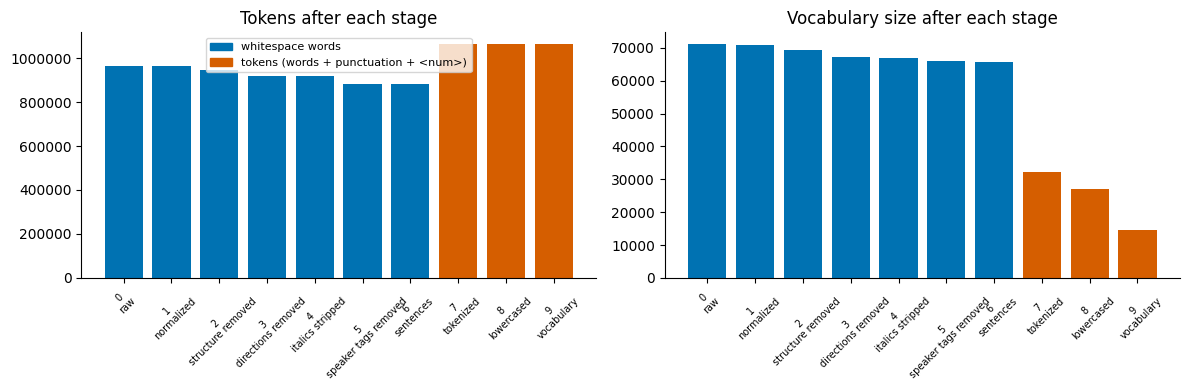

In [9]:
stage_df = pd.read_csv(TAB_DIR / "preprocessing_stages.csv")
stage_df["tokens_removed_vs_previous"] = stage_df["n_tokens"].diff().where(stage_df["unit"].eq(stage_df["unit"].shift()))
display(stage_df[["stage", "name", "unit", "n_tokens", "vocab_size", "n_sentences", "tokens_removed_vs_previous", "description"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#0072B2" if u == "whitespace words" else "#D55E00" for u in stage_df["unit"]]
labels = [f"{s}\n{n.replace('_', ' ')}" for s, n in zip(stage_df["stage"], stage_df["name"])]
for ax, col, ttl in zip(axes, ["n_tokens", "vocab_size"], ["Tokens after each stage", "Vocabulary size after each stage"]):
    ax.bar(labels, stage_df[col], color=colors)
    ax.set_title(ttl); ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.ticklabel_format(axis="y", style="plain")
axes[0].legend([plt.Rectangle((0, 0), 1, 1, color="#0072B2"), plt.Rectangle((0, 0), 1, 1, color="#D55E00")],
               ["whitespace words", "tokens (words + punctuation + <num>)"], fontsize=8)
plt.tight_layout()
save_fig(fig, "preprocessing_stage_counts.png")
plt.show()

Removing structure, directions and speaker tags takes out about 80k whitespace words (≈ 8 %) – boilerplate a keyboard would never need to predict. Stage 6 shows *more* whitespace words than stage 5 (+725) only because a sentence boundary can split one whitespace word in two (`captivity.—Hail,` → `captivity.` + `—Hail,`). Tokenizing raises the token count because punctuation becomes separate tokens and hyphenated words split, and it roughly **halves the vocabulary** (65.6k → 32.1k types) because `king,` `king.` `king` collapse to one type; lowercasing removes another ~5k types, and the `min_freq = 2` cut (words seen only once in train) halves it again to 14.7k.

## 4. Final vocabulary, `<unk>` and OOV rates
`<unk>` rates are recomputed against the **final** vocabulary. "Word" tokens exclude punctuation, `<num>` and boundary tokens; "types" are distinct lowercase word types.

In [10]:
vocab = D.load_vocab()
vset = set(vocab.itos)
special_or_punct = set(D.SPECIALS) | set(D.PUNCT)


def split_tokens(sp):
    out = []
    for s in meta["slug"]:
        if split_of[s] == sp:
            out.extend(t for l in load_stage(8, s) for t in l.split())
    return out


rows = []
for sp in ("train", "val", "test"):
    toks = split_tokens(sp)
    words = [t for t in toks if t not in special_or_punct]
    types = set(words)
    rows.append({
        "split": sp, "tokens": len(toks), "word_tokens": len(words),
        "unk_pct_all_tokens": round(100 * sum(t not in vset for t in toks) / len(toks), 2),
        "unk_pct_word_tokens": round(100 * sum(t not in vset for t in words) / len(words), 2),
        "word_types": len(types),
        "oov_pct_word_types": round(100 * sum(t not in vset for t in types) / len(types), 2),
    })
oov = pd.DataFrame(rows)
display(oov)
save_table(oov, "preprocessing_oov.csv")

eda = TAB_DIR / "oov_coverage.csv"
if eda.exists():
    e = pd.read_csv(eda).iloc[:2][["evaluated_set", "pct_oov_tokens", "pct_oov_types"]]
    print("\nFor comparison, EDA notebook (train vocabulary with NO min_freq cut, raw tokenizer):")
    display(e)

# check: <unk> in the saved files agrees with the recomputation
for sp in ("val", "test"):
    saved = [t for l in P.read(PROCESSED / f"{sp}.txt").splitlines() for t in l.split()]
    print(f"{sp}.txt: {len(saved):,} tokens, <unk> = {saved.count('<unk>'):,} "
          f"({100 * saved.count('<unk>') / len(saved):.2f} % of all tokens)")

top = pd.DataFrame([(t, vocab.counts[t]) for t in vocab.itos[:50]], columns=["token", "train_count"])
print(f"\nvocabulary: {len(vocab):,} entries = {len(D.SPECIALS)} special + {len(D.PUNCT)} punctuation + {len(vocab) - 10:,} words (train count >= 2)")
display(top.head(25).T)

,split,tokens,word_tokens,unk_pct_all_tokens,unk_pct_word_tokens,word_types,oov_pct_word_types
0,train,842748,703948,1.16,1.39,24454,39.87
1,val,119916,100177,2.70,3.23,9149,24.00
2,test,101145,84068,2.81,3.38,8577,23.80


saved table  -> tables/preprocessing_oov.csv

For comparison, EDA notebook (train vocabulary with NO min_freq cut, raw tokenizer):


,evaluated_set,pct_oov_tokens,pct_oov_types
0,test vs train vocabulary,4.13,14.80
1,val vs train vocabulary,3.53,14.71


val.txt: 119,916 tokens, <unk> = 3,238 (2.70 % of all tokens)
test.txt: 101,145 tokens, <unk> = 2,839 (2.81 % of all tokens)

vocabulary: 14,713 entries = 4 special + 6 punctuation + 14,703 words (train count >= 2)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
token,<s>,</s>,<unk>,<num>,.,",",;,:,!,?,...,a,you,my,that,in,is,not,it,for,me
train_count,53331,53331,9751,311,38077,72740,10115,2619,5950,8988,...,11940,11390,10284,9370,9353,7653,7082,6570,6527,6471


The `min_freq = 2` cut maps words seen once in train to `<unk>`, so training data itself contains `<unk>` (needed so the models learn how to predict it). Test/val `<unk>` rates are dominated by character names and rare words of the held-out plays – as in the EDA – plus the rare train words that fell below the cut.

### Why is the test unknown-word rate *lower* than in the EDA?
The EDA measured 4.1 % of test tokens outside the train vocabulary, now it is 3.4 % of word tokens, although a `min_freq` cut should *raise* the rate. Decomposition on the test works (word tokens only, same train/test works every time):

In [11]:
EDA_TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)*")


def eda_tokens(text):
    return EDA_TOKEN.findall(text.replace("’", "'").replace("‘", "'").lower())


train_s = [s for s in meta["slug"] if split_of[s] == "train"]
test_s = [s for s in meta["slug"] if split_of[s] == "test"]
raw_train, raw_test, clean_train, clean_test, kept = Counter(), Counter(), Counter(), Counter(), Counter()
for s in train_s:
    raw_train.update(eda_tokens(raw[s]))
    clean_train.update(t for l in load_stage(8, s) for t in l.split() if t not in special_or_punct)
for s in test_s:
    raw_test.update(eda_tokens(raw[s]))
    clean_test.update(t for l in load_stage(8, s) for t in l.split() if t not in special_or_punct)
    kept.update(eda_tokens(P.read(INTERIM / STAGE_DIRS[5] / f"{s}.txt")))     # same tokenizer, cleaned text


def oov_pct(test, train, min_freq):
    v = {w for w, c in train.items() if c >= min_freq}
    return 100 * sum(c for w, c in test.items() if w not in v) / sum(test.values())


dec = pd.DataFrame([
    {"step": "A  EDA: raw text (tags, directions, headers included), vocab = all train types", "test_word_tokens": sum(raw_test.values()), "oov_pct": oov_pct(raw_test, raw_train, 1)},
    {"step": "B  same raw text, but train vocab with min_freq = 2", "test_word_tokens": sum(raw_test.values()), "oov_pct": oov_pct(raw_test, raw_train, 2)},
    {"step": "C  cleaned text, vocab = all train types (no min_freq)", "test_word_tokens": sum(clean_test.values()), "oov_pct": oov_pct(clean_test, clean_train, 1)},
    {"step": "D  cleaned text, min_freq = 2  (= final)", "test_word_tokens": sum(clean_test.values()), "oov_pct": oov_pct(clean_test, clean_train, 2)},
])
dec["oov_pct"] = dec["oov_pct"].round(2)
display(dec)
save_table(dec, "preprocessing_oov_decomposition.csv")

removed = raw_test - kept                                  # test tokens deleted by the cleaning
v1 = set(raw_train)
mech = pd.DataFrame([
    {"group": "test tokens removed by cleaning (speaker tags, directions, headers, front matter)",
     "tokens": sum(removed.values()), "pct_oov_vs_train_vocab": round(100 * sum(c for w, c in removed.items() if w not in v1) / sum(removed.values()), 1)},
    {"group": "test tokens kept (the actual speech)",
     "tokens": sum(kept.values()), "pct_oov_vs_train_vocab": round(100 * sum(c for w, c in kept.items() if w not in v1) / sum(kept.values()), 1)},
])
display(mech)
save_table(mech, "preprocessing_oov_mechanism.csv")
print("most frequent removed test tokens that are OOV:", [(w, c) for w, c in removed.most_common() if w not in v1][:12])

,step,test_word_tokens,oov_pct
0,"A EDA: raw text (tags, directions, headers included), vocab = all train types",93104,4.13
1,"B same raw text, but train vocab with min_freq = 2",93104,5.30
2,"C cleaned text, vocab = all train types (no min_freq)",84068,2.29
3,"D cleaned text, min_freq = 2 (= final)",84068,3.38


saved table  -> tables/preprocessing_oov_decomposition.csv


,group,tokens,pct_oov_vs_train_vocab
0,"test tokens removed by cleaning (speaker tags, directions, headers, front matter)",9031,22.1
1,test tokens kept (the actual speech),84073,2.2


saved table  -> tables/preprocessing_oov_mechanism.csv
most frequent removed test tokens that are OOV: [('toby', 171), ('enobarbus', 140), ('viola', 136), ('prospero', 134), ('olivia', 132), ('malvolio', 97), ('charmian', 81), ('ariel', 74), ('cade', 70), ('fabian', 67), ('caliban', 61), ('miranda', 58)]


**Reading the table:** the `min_freq = 2` cut does raise the rate (A → B, and C → D). What lowers it is the *cleaning* (A → C): the speaker tags and stage directions of the held-out plays are packed with character names that never occur in the train plays (*toby, olivia, prospero, enobarbus, ...*), so those removed tokens had a far higher OOV rate than the speech that remains.

## 5. Case map
Case is lost at lowercasing, so the most frequent casing of every word *when it is not the first word of a verse line or sentence* is saved (train works only) in `data/processed/case_map.json`. It lets the keyboard demo display `i → I`, `hamlet → Hamlet`.

In [12]:
case_map = D.load_case_map()
changed = {w: c for w, c in case_map.items() if c != w}
print(f"{len(case_map):,} words in the case map, {len(changed):,} of them are not all-lowercase")
print({w: case_map[w] for w in ["i", "o", "hamlet", "london", "god", "caesar", "king", "lord", "the"] if w in case_map})
print("\nRestoring display case on the first test sentences:")
for sent in D.read_sentences("test")[100:106]:
    print(" ", D.restore_case(sent, case_map))

23,472 words in the case map, 2,039 of them are not all-lowercase
{'i': 'I', 'o': 'O', 'hamlet': 'Hamlet', 'london': 'London', 'god': 'God', 'caesar': 'Caesar', 'king': 'King', 'lord': 'lord', 'the': 'the'}

Restoring display case on the first test sentences:
  His fortune!
  O, let him marry a woman that cannot go, sweet <unk>, I beseech thee, and let her die too, and give him a worse, and let worse follow worse, till the worst of all follow him laughing to his grave, <unk> a cuckold!
  Good <unk>, hear me this prayer, though thou deny me a matter of more weight; good <unk>, I beseech thee!
  Amen.
  Dear goddess, hear that prayer of the people!
  For, as it is a <unk> to see a handsome man loose wived, so it is a deadly sorrow to behold a foul knave <unk>.


## 6. Before / after word clouds
Same recipe as the EDA clouds (NLTK English stopwords + *thou, thee, thy, thine, hath, doth, art* removed). *Before*: the raw works with the EDA tokenizer – speaker names and stage-direction words dominate. *After*: the final processed files (punctuation, `<num>` and `<unk>` removed).

saved figure -> figures/preprocessing_wordclouds_before_after.png


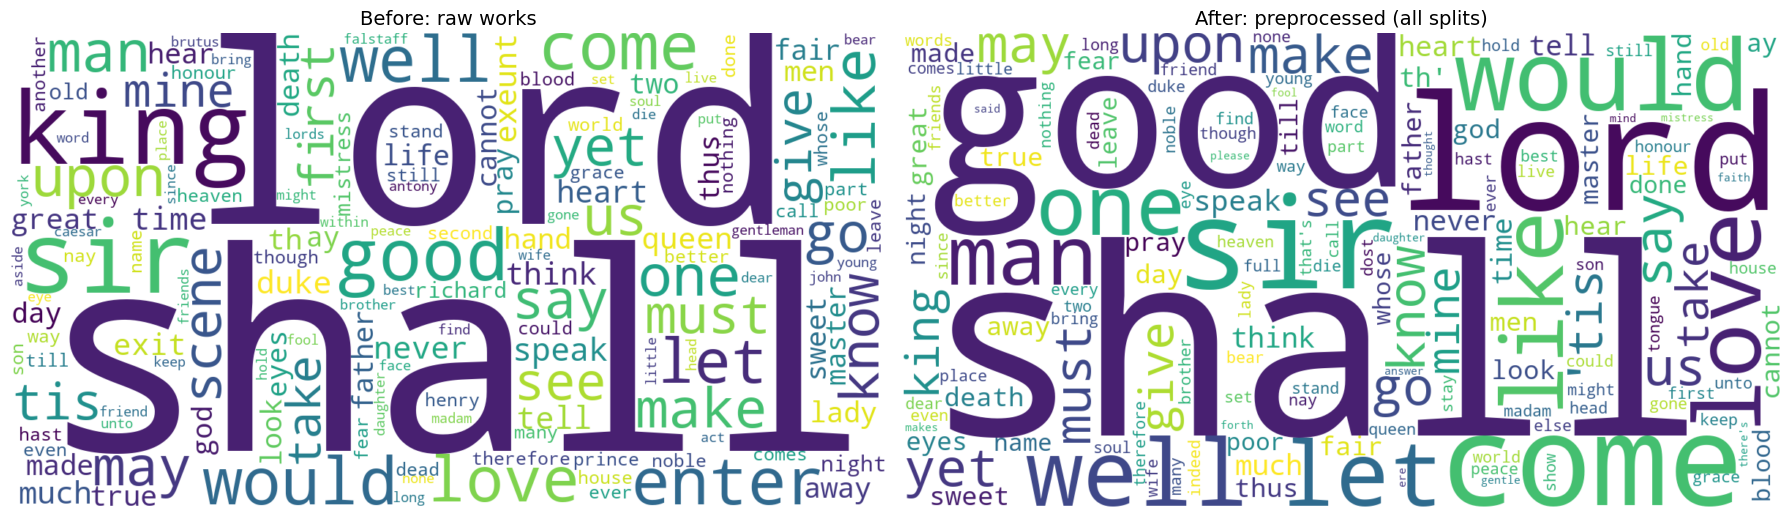

,enter,exeunt,exit,scene,act,hamlet,lord,king
before_count,2487,1095,1041,1631,519,461,3134,3015
after_count,101,0,3,37,135,74,2741,1384


In [13]:
STOP = set(stopwords.words("english")) | {"thou", "thee", "thy", "thine", "hath", "doth", "art"}
EDA_TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)*")
before = Counter()
for s in meta["slug"]:
    before.update(t for t in EDA_TOKEN.findall(raw[s].replace("\u2019", "'").replace("\u2018", "'").lower()) if t not in STOP)
after = Counter()
for sp in ("train", "val", "test"):
    for l in P.read(PROCESSED / f"{sp}.txt").splitlines():
        after.update(t for t in l.split() if t not in special_or_punct and t not in STOP)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, cnt, ttl in zip(axes, [before, after], ["Before: raw works", "After: preprocessed (all splits)"]):
    wc = WordCloud(width=1200, height=650, background_color="white", max_words=150, colormap="viridis",
                   random_state=SEED).generate_from_frequencies(cnt)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(ttl, fontsize=14)
plt.tight_layout()
save_fig(fig, "preprocessing_wordclouds_before_after.png")
plt.show()

cmp = pd.DataFrame({"before_count": {w: before[w] for w in ["enter", "exeunt", "exit", "scene", "act", "hamlet", "lord", "king"]},
                    "after_count": {w: after[w] for w in ["enter", "exeunt", "exit", "scene", "act", "hamlet", "lord", "king"]}})
display(cmp.T)

Structure words (*enter, exeunt, exit, scene, act*) all but disappear and character names lose their speaker-tag inflation (they still occur naturally inside speeches, e.g. *my lord Hamlet*). The few remaining *enter/act/scene* are ordinary uses of those English words (*"enter my house"*, *"act"*).

## 7. WikiText-2 (same punctuation / apostrophe / lowercase rules, no vocabulary yet)
Tokenized with the same rules (digits → `<num>`, hyphens split, only the 6 punctuation marks, apostrophes inside words, lowercase). WikiText-2's own pre-tokenization is undone first: `game 's → game's`, `wasn 't → wasn't`, `1 @,@ 000 → 1000`, ` @-@ ` → hyphen (then split). Output is one *paragraph* per line, because sentence splitting and the vocabulary are decided later, when the baseline is built.

In [14]:
rows = []
for sp in ("train", "val", "test"):
    p = PROCESSED / f"wikitext2_{sp}.txt"
    lines = P.read(p).splitlines()
    toks = [t for l in lines for t in l.split()]
    rows.append({"split": sp, "paragraphs": len(lines), "tokens": len(toks), "types": len(set(toks))})
wiki = pd.DataFrame(rows)
display(wiki)
save_table(wiki, "preprocessing_wikitext2.csv")

src_lines = [l for l in P.read(ROOT / "data" / "baseline" / "wikitext2_train.txt").splitlines() if l.strip() and not l.strip().startswith("=")]
k = next(i for i, l in enumerate(src_lines) if "@-@" in l and " 's" in l)
print("\nBEFORE:", src_lines[k][:260])
print("AFTER :", " ".join(P.tokenize_wikitext_line(src_lines[k]))[:260])

,split,paragraphs,tokens,types
0,train,23766,1919779,66120
1,val,2461,200972,17027
2,test,2891,225655,18281


saved table  -> tables/preprocessing_wikitext2.csv

BEFORE:  As with previous Valkyira Chronicles games , Valkyria Chronicles III is a tactical role @-@ playing game where players take control of a military unit and take part in missions against enemy forces . Stories are told through comic book @-@ like panels with an
AFTER : as with previous valkyira chronicles games , valkyria chronicles iii is a tactical role playing game where players take control of a military unit and take part in missions against enemy forces . stories are told through comic book like panels with animated ch


## 8. Quality checks and known residue
Checks on the final data: leftover structure words, ALL-CAPS words that survived (unmatched tags), and the sentence length distribution (relevant for model input length).

In [15]:
final = {sp: [l.split() for l in P.read(PROCESSED / f"{sp}.txt").splitlines()] for sp in ("train", "val", "test")}
all_sents = [s for v in final.values() for s in v]

lead = Counter(s[0] for s in all_sents)
dir_words = ["enter", "exit", "exeunt", "re-enter", "flourish", "alarum", "alarums", "sennet", "scene", "act", "aside", "song"]
res = pd.DataFrame({"sentences_starting_with": {w: lead[w] for w in dir_words}})
res["of_total_sentences_pct"] = (100 * res["sentences_starting_with"] / len(all_sents)).round(3)
display(res.T)
save_table(res, "preprocessing_residuals.csv", index=True)

,enter,exit,exeunt,re-enter,flourish,alarum,alarums,sennet,scene,act,aside,song
sentences_starting_with,7.00,0.0,0.0,0.0,1.000,2.000,0.0,0.0,0.0,0.0,3.000,1.000
of_total_sentences_pct,0.01,0.0,0.0,0.0,0.001,0.003,0.0,0.0,0.0,0.0,0.004,0.001


saved table  -> tables/preprocessing_residuals.csv


### Quantified residue
Counts of structure that is still in the text, as a share of the whitespace words that remain after stage 5 (the stage where tags are gone; denominator below). Three kinds:
1. **Lines starting with `Enter / Exit / Exeunt / Re-enter`** that survived (a *direction-like* one has a capitalised name after the keyword, e.g. `Re-enter Charles ...`; the others are the ordinary verb: *"Enter our gates"*).
2. **Un-bracketed directions that can still be detected**: paragraphs indented by one space (the Gutenberg layout for directions) that stage 3 left alone because they have no `Enter/Exit` keyword (*"She addresses her to a Lord."*). A detector marks them as direction-like when they contain no `!`/`?` and no first/second-person pronoun (spoken text almost always does).
3. **ALL-CAPS tokens** (2+ letters) left in the text – unmatched speaker tags, headings.

In [16]:
total5 = int(stage_df.loc[stage_df["stage"] == 5, "n_tokens"].iloc[0])
KW = re.compile(r"^(Enter|Exit|Exeunt|Re-enter)\b")
PRON = {"i", "me", "my", "mine", "you", "your", "thou", "thee", "thy", "thine", "we", "us", "our"}
plays = [s for s in meta["slug"] if is_play[s]]

# 1. lines starting with a direction keyword after stage 5
kw_lines = [(s, l.strip()) for s in plays for l in load_stage(5, s) if KW.match(l.strip())]


def direction_like(l):
    w = l.split()
    return w[0] == "Re-enter" or (len(w) > 1 and (w[1][:1].isupper() or (w[1] in ("a", "an", "the") and any(x[:1].isupper() for x in w[2:6]))))


kw_dir = [(s, l) for s, l in kw_lines if direction_like(l)]

# 2. one-space-indented paragraphs that survived stage 3
indented = []
for s in plays:
    for p in P.paragraphs(P.read(INTERIM / STAGE_DIRS[3] / f"{s}.txt")):
        if all(re.match(r"^ \S", l) for l in p):
            text = " ".join(x.strip() for x in p)
            words = set(re.findall(r"[a-z']+", text.lower()))
            indented.append((s, text, not (set("!?") & set(text)) and not (words & PRON) and len(text.split()) <= 40))
ind_dir = [(s, t) for s, t, ok in indented if ok]

# 3. ALL-CAPS tokens left after stage 5
caps, caps_poem = Counter(), Counter()
for s in meta["slug"]:
    for w in re.findall(r"\b[^\W\d_a-z]{2,}\b", P.read(INTERIM / STAGE_DIRS[5] / f"{s}.txt")):
        if w.isupper() and not re.fullmatch(r"[IVXLC]+", w):
            (caps if is_play[s] else caps_poem)[w] += 1

nw = lambda items: sum(len(t.split()) for _, t in items)
rows = [
    {"residue": "lines starting with Enter/Exit/Exeunt/Re-enter", "count": len(kw_lines), "unit": "lines",
     "of_which_direction_like": len(kw_dir), "direction_like_tokens": nw(kw_dir)},
    {"residue": "un-bracketed 1-space-indented paragraphs (no keyword)", "count": len(indented), "unit": "paragraphs",
     "of_which_direction_like": len(ind_dir), "direction_like_tokens": nw(ind_dir)},
    {"residue": "ALL-CAPS tokens in plays (unmatched tags / headings)", "count": sum(caps.values()), "unit": "tokens",
     "of_which_direction_like": sum(caps.values()), "direction_like_tokens": sum(caps.values())},
    {"residue": "ALL-CAPS tokens in poems (dedications, kept on purpose)", "count": sum(caps_poem.values()), "unit": "tokens",
     "of_which_direction_like": 0, "direction_like_tokens": 0},
]
resid = pd.DataFrame(rows)
tot_resid = nw(kw_dir) + nw(ind_dir) + sum(caps.values())
resid["pct_of_tokens"] = (100 * resid["direction_like_tokens"] / total5).round(4)
display(resid)
print(f"denominator: {total5:,} whitespace words after stage 5")
print(f"Total detectable residue to remove (direction-like + ALL-CAPS in plays): {tot_resid:,} tokens = {100 * tot_resid / total5:.3f} % of tokens")
resid.loc[len(resid)] = ["TOTAL detectable residue (rows 1-3, direction-like)", None, "tokens", None, tot_resid, round(100 * tot_resid / total5, 4)]
save_table(resid, "preprocessing_residue.csv")
print("\nEnter/Exit lines found:"); [print("  ", s[:14], "|", l[:70], "<- direction" if direction_like(l) else "") for s, l in kw_lines]
print("\nIndented paragraphs flagged direction-like:", len(ind_dir), "| NOT flagged (spoken text, kept):")
[print("  ", s[:14], "|", t[:75]) for s, t, ok in indented if not ok]
print("\nALL-CAPS in plays:", caps.most_common(15))

,residue,count,unit,of_which_direction_like,direction_like_tokens,pct_of_tokens
0,lines starting with Enter/Exit/Exeunt/Re-enter,8,lines,2,19,0.0022
1,un-bracketed 1-space-indented paragraphs (no keyword),35,paragraphs,29,266,0.0301
2,ALL-CAPS tokens in plays (unmatched tags / headings),5,tokens,5,5,0.0006
3,"ALL-CAPS tokens in poems (dedications, kept on purpose)",28,tokens,0,0,0.0000


denominator: 883,468 whitespace words after stage 5
Total detectable residue to remove (direction-like + ALL-CAPS in plays): 290 tokens = 0.033 % of tokens
saved table  -> tables/preprocessing_residue.csv

Enter/Exit lines found:
   antony_and_cle | Enter the city, clip your wives, your friends, 
   hamlet_prince_ | Enter a King and a Queen very lovingly; the Queen embracing him and he <- direction
   king_henry_the | Enter our gates; dispose of us and ours; 
   first_part_of_ | Re-enter Charles, Alençon and Reignier. <- direction
   first_part_of_ | Enter and cry, "The Dauphin!" presently, 
   second_part_of | Enter his chamber, view his breathless corpse, 
   merchant_of_ve | Enter'd my house. Antonio, you are welcome, 
   troilus_and_cr | Enter his thoughts, save such as doth revolve 

Indented paragraphs flagged direction-like: 29 | NOT flagged (spoken text, kept):
   othello_the_mo | A sail, a sail, a sail!
   othello_the_mo | A sail, a sail!
   tempest | A plague upon this howlin

In [17]:
# sentence-count reconciliation: where did the "58 missing sentences" go?
frag = Counter()
for s in meta["slug"]:
    for unit in P.read(INTERIM / STAGE_DIRS[5] / f"{s}.txt").split("\n\n"):
        for x in P.split_sentences(re.sub(r"\s+", " ", unit).strip()):
            if not re.search(r"\w", x):
                frag[x] += 1
n6 = int(stage_df.loc[stage_df["stage"] == 6, "n_sentences"].iloc[0])
n_final = sum(len(P.read(PROCESSED / f"{sp}.txt").splitlines()) for sp in ("train", "val", "test"))
print(f"punctuation-only fragments produced by the splitter and now dropped at stage 6: {sum(frag.values())} {dict(frag)}")
print(f"sentences after stage 6 = {n6:,};  sentences in train+val+test.txt = {n_final:,};  works_index total = {int(D.load_works_index()['n_sentences'].sum()):,}")
assert n6 == n_final

punctuation-only fragments produced by the splitter and now dropped at stage 6: 58 {'—': 11, '.': 47}
sentences after stage 6 = 68,379;  sentences in train+val+test.txt = 68,379;  works_index total = 68,379


,count,mean,std,min,50%,90%,95%,99%,max
tokens_per_sentence,68379.0,15.6,14.4,1.0,11.0,33.0,43.0,72.0,226.0


saved figure -> figures/preprocessing_sentence_length.png


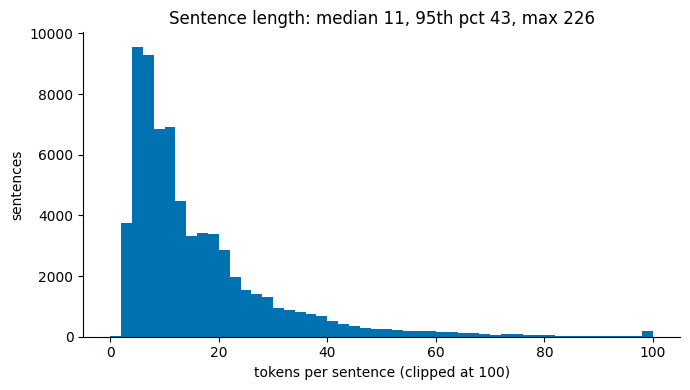

163 sentences are longer than 100 tokens (mostly sonnets and long verse periods, which are single sentences by the punctuation rule)


In [18]:
lens = np.array([len(s) for s in all_sents])
q = pd.Series(lens).describe(percentiles=[.5, .9, .95, .99]).round(1)
display(q.to_frame("tokens_per_sentence").T)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.minimum(lens, 100), bins=np.arange(0, 102, 2), color="#0072B2")
ax.set_xlabel("tokens per sentence (clipped at 100)"); ax.set_ylabel("sentences")
ax.set_title(f"Sentence length: median {np.median(lens):.0f}, 95th pct {np.percentile(lens, 95):.0f}, max {lens.max()}")
plt.tight_layout()
save_fig(fig, "preprocessing_sentence_length.png")
plt.show()
print(f"{(lens > 100).sum()} sentences are longer than 100 tokens (mostly sonnets and long verse periods, which are single sentences by the punctuation rule)")

## Summary

1. **Structure and noise removed:** 963,240 raw whitespace words become 883,468 (−8.3 %): front matter, ACT/SCENE headers and the Latin epigraph −17.0k, stage directions −26.0k, speaker tags −36.7k. Structure words (*enter, exeunt, scene*) drop from thousands of occurrences to a handful of ordinary uses.
2. **Italics:** 86 % of the 4,851 `_italic_` spans lie inside `[...]` directions, so brackets were used to find directions; the remaining italics (Latin/French, songs, letters) are real text and kept with the underscores stripped.
3. **Quotes and apostrophes:** 372 single-quote quotation marks (mostly in comedies and tragedies, plus *A Lover's Complaint*, the Sonnets and *Lucrece*) were stripped without touching elisions; apostrophes stay inside words, so `'tis`, `o'er`, `th'`, `kill'd`, `Caesar's` are single tokens (the corpus uses curly apostrophes throughout: 26,332 curly vs 1 straight).
4. **Sentences:** speeches are joined and split at `. ! ?`, giving **68,379 sentences** (stage table, the processed files and `works_index.csv` now agree; 58 punctuation-only fragments such as dotted leaders `. . . .` are dropped at stage 6). Median 11 tokens, 95th percentile 43, max 226; 163 sentences exceed 100 tokens because sonnets and long verse periods are a single sentence.
5. **Tokens:** 1,063,809 tokens (842,748 train / 119,916 val / 101,145 test) from 6 punctuation marks, `<num>` and words; hyphenated words are split, digits are `<num>`, and tokenizing alone halves the type count (65.6k → 32.1k) because punctuation is no longer glued to words.
6. **Vocabulary:** built on the 36 train works only with `min_freq = 2`: 14,713 entries (4 special + 6 punctuation + 14,703 words); 9,751 train word types seen once become `<unk>` (1.4 % of train word tokens).
7. **OOV after preprocessing:** `<unk>` is 2.70 % of val and 2.81 % of test tokens (3.23 % / 3.38 % of word tokens). The test rate is *below* the EDA's 4.13 % because cleaning removed the speaker tags and directions of the held-out plays, whose tokens were full of unseen character names (22 % OOV vs 2.2 % for the speech that remains): cleaning alone takes 4.13 % → 2.29 %, and the `min_freq = 2` cut then raises it to 3.38 %.
8. **Case map:** 23,478 words with their most frequent mid-sentence casing (2,040 non-lowercase, e.g. *I, O, Hamlet, London*), computed on train works only, for display in the keyboard demo.
9. **WikiText-2:** tokenized with the same punctuation/apostrophe/lowercase rules (clitics glued back, `@-@` dropped), saved as 23,766 / 2,461 / 2,891 paragraphs (1.92M / 0.20M / 0.23M tokens in train / val / test); no vocabulary yet.
10. **Residue (quantified):** 290 tokens = **0.033 %** of the text are detectable leftovers: 2 direction-like `Enter/Re-enter` lines (19 tokens), 29 un-bracketed indented direction paragraphs without a keyword (266 tokens, e.g. *"She addresses her to a Lord."*) and 5 ALL-CAPS tokens in plays; the 28 ALL-CAPS tokens in the *Venus and Adonis* / *Lucrece* dedications are kept on purpose (the Latin epigraph is dropped). The Richard II / Pericles boundary bug is fixed at the source (`get_shakespeare.py`).